In [1]:
# === Core Python Utilities ===
import os
import re
import math
import random
import warnings
from datetime import datetime
from itertools import combinations
from collections import Counter
from typing import List, Tuple, Dict, Optional

# === Scientific Computing ===
import numpy as np
import pandas as pd
import scipy
from scipy.stats import skew

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import missingno
import mplcursors
from matplotlib.colors import LinearSegmentedColormap

# === Progress & Optimization ===
from tqdm.notebook import tqdm
tqdm.pandas()
import optuna

# === Data Preprocessing ===
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, PowerTransformer,
    OneHotEncoder, LabelEncoder, OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE


# === Train/Test Splits & Cross-Validation ===
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold,
    cross_val_predict, cross_val_score,
    GridSearchCV, RandomizedSearchCV, ParameterGrid
)

# === Metrics & Evaluation ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, auc, roc_curve,
    classification_report, confusion_matrix,
    precision_recall_curve, make_scorer
)

from sklearn.decomposition import PCA
# === Pipelines ===
from sklearn.pipeline import make_pipeline

# === Machine Learning Models ===
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
import xgboost as xgb

from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

# from catboost import CatBoostClassifier, CatBoostRegressor, Pool, cv
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import optuna

In [2]:
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
from scr.machine_learning.training_module import (
    evaluate_model,                     # Hàm thực hiện đánh giá mô hình trên tập dev và test
    optimize_threshold_by_f1           # Hàm thực hiện tối ưu hoá ngưỡng phân loại
)

In [3]:
# Một số setting cơ bản
import warnings
import pandas as pd
warnings.filterwarnings ('ignore')
pd.set_option ('display.width', None)
pd.set_option ('display.max_rows', 100)
pd.set_option ('display.max_columns', 50)

In [4]:
file_path = '/Users/kittnguyen/Documents/us-flight-project/data/silver_data/'
X_train = np.load(f"{file_path}train/X_train.npy", allow_pickle=True)
y_train = np.load(f"{file_path}train/y_train.npy", allow_pickle=True)
X_dev = np.load(f"{file_path}dev/X_dev.npy", allow_pickle=True)
y_dev = np.load(f"{file_path}dev/y_dev.npy", allow_pickle=True)
X_test = np.load(f"{file_path}test/X_test.npy", allow_pickle=True)
y_test = np.load(f"{file_path}test/y_test.npy", allow_pickle=True)

# Multilayer Perceptron

## a. From Scikit-learn

### Training

In [6]:
# -- MLP Classifier ---
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),   # 3 tầng ẩn
    activation='relu',                  # hàm kích hoạt
    solver='adam',                      # optimizer
    alpha=1e-4,                         # hệ số regularization
    batch_size=256,
    # learning_rate_init=0.001,
    learning_rate='adaptive',
    max_iter=50,                        # 100 - 200
    random_state=42,
    verbose=True,                        # in log huấn luyện
    early_stopping=True,
    validation_fraction=0.2
)

# --- Training ---
mlp_model.fit(X_train, y_train)

Iteration 1, loss = 0.60195108
Validation score: 0.685233
Iteration 2, loss = 0.59653463
Validation score: 0.687494
Iteration 3, loss = 0.59409953
Validation score: 0.688757
Iteration 4, loss = 0.59251329
Validation score: 0.689703
Iteration 5, loss = 0.59135654
Validation score: 0.690324
Iteration 6, loss = 0.59045673
Validation score: 0.691276
Iteration 7, loss = 0.58970001
Validation score: 0.691103
Iteration 8, loss = 0.58913428
Validation score: 0.691556
Iteration 9, loss = 0.58852829
Validation score: 0.691855
Iteration 10, loss = 0.58806062
Validation score: 0.692264
Iteration 11, loss = 0.58760569
Validation score: 0.691647
Iteration 12, loss = 0.58729654
Validation score: 0.692414
Iteration 13, loss = 0.58690957
Validation score: 0.693025
Iteration 14, loss = 0.58671496
Validation score: 0.692785
Iteration 15, loss = 0.58640554
Validation score: 0.692547
Iteration 16, loss = 0.58617620
Validation score: 0.693648
Iteration 17, loss = 0.58594531
Validation score: 0.693236
Iterat

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,256
,learning_rate,'adaptive'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,50
,shuffle,True
,random_state,42


### Predicting & Evaluating

#### Dev

Evaluation on  set:
Accuracy : 0.6926
Precision: 0.6464
Recall   : 0.417
F1-score : 0.507
ROC AUC  : 0.7191


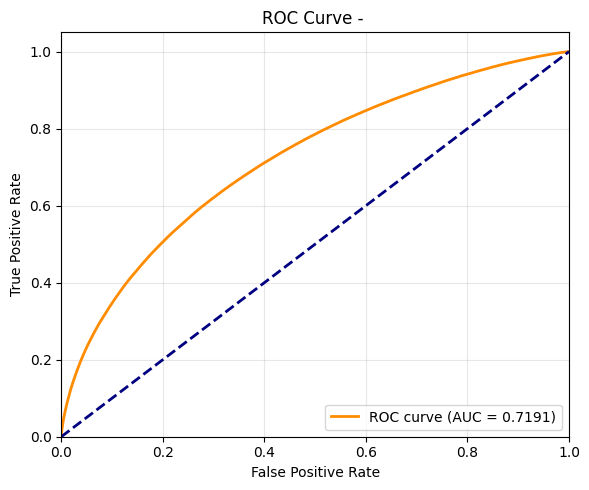

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.86      0.78    837529
           1       0.65      0.42      0.51    511152

    accuracy                           0.69   1348681
   macro avg       0.68      0.64      0.64   1348681
weighted avg       0.68      0.69      0.67   1348681



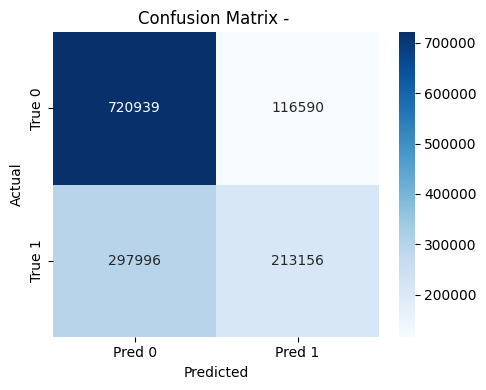

Best threshold: 0.50 with F1-score: 1.0000


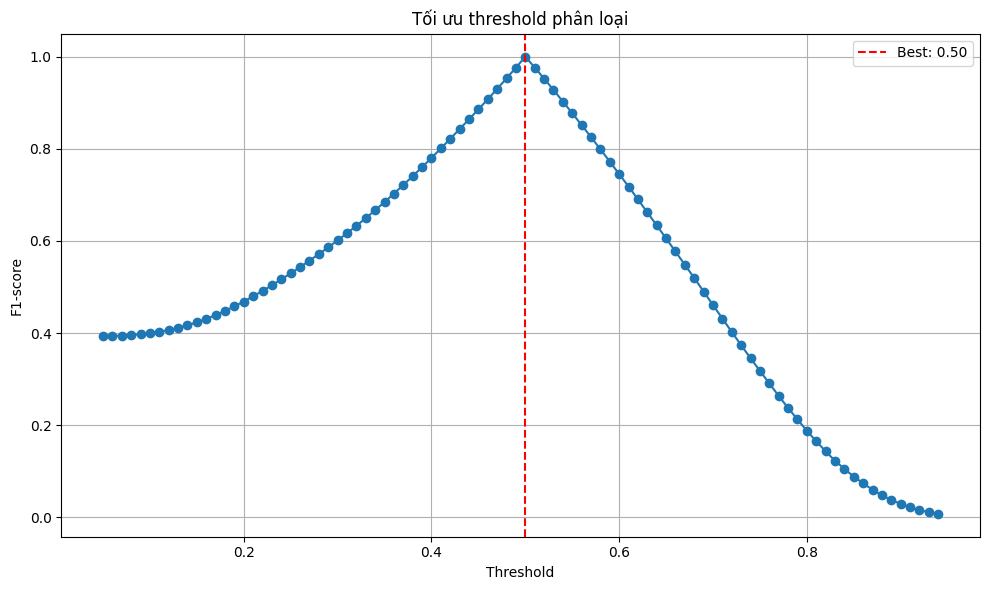

(np.float64(0.5000000000000001), 1.0)

In [6]:
# --- Predicting ---
y_pred_dev = mlp_model.predict(X_dev)
y_proba_dev = mlp_model.predict_proba(X_dev)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_dev, y_pred_dev, y_proba_dev)

# --- Optimizing ---
optimize_threshold_by_f1 (mlp_model, X_dev, y_pred_dev)

#### Test

Evaluation on  set:
Accuracy : 0.6931
Precision: 0.6474
Recall   : 0.4175
F1-score : 0.5076
ROC AUC  : 0.7198


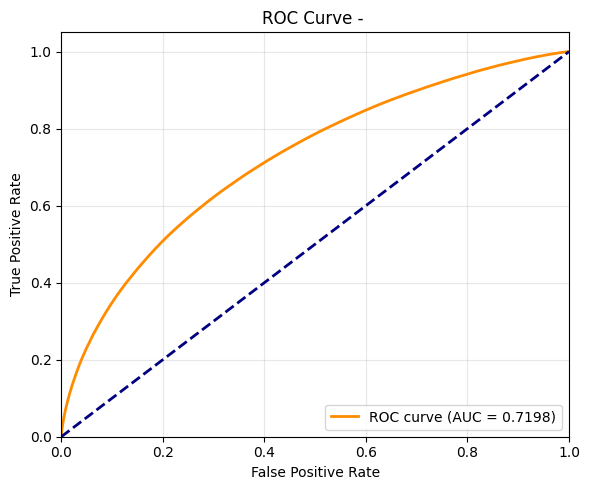

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.86      0.78    837529
           1       0.65      0.42      0.51    511152

    accuracy                           0.69   1348681
   macro avg       0.68      0.64      0.64   1348681
weighted avg       0.68      0.69      0.67   1348681



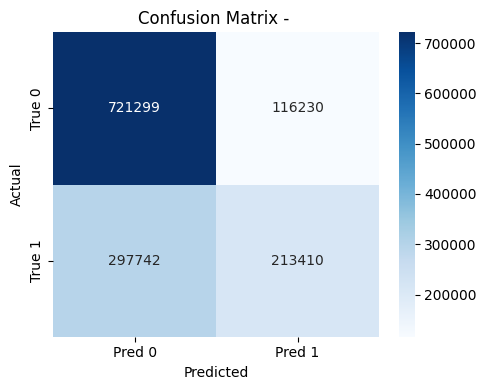

Best threshold: 0.50 with F1-score: 1.0000


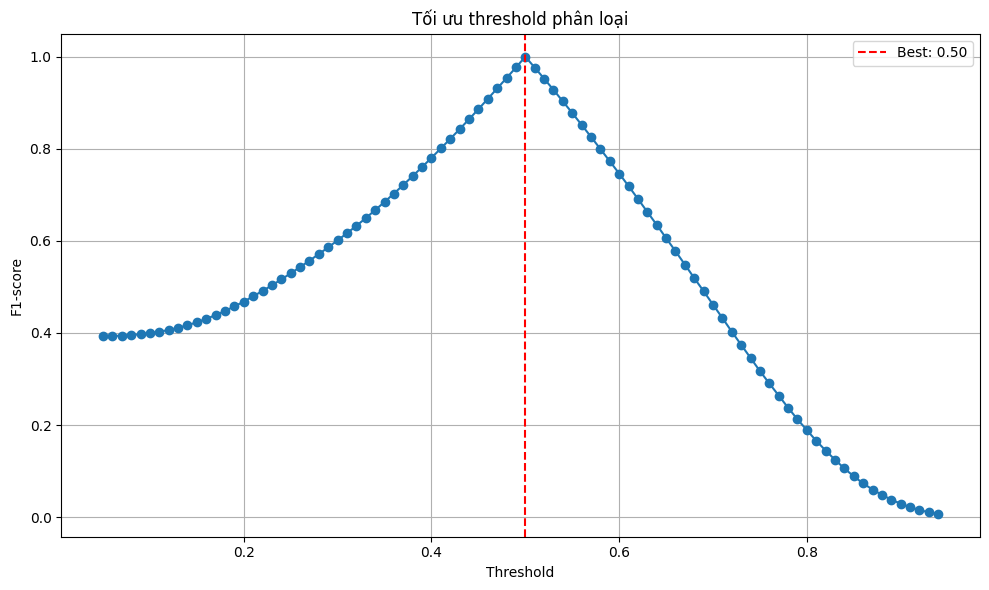

(np.float64(0.5000000000000001), 1.0)

In [7]:
# --- Predicting ---
y_pred_test = mlp_model.predict(X_test)
y_proba_test = mlp_model.predict_proba(X_test)[:, 1] # Probability

# --- Evaluating ---
evaluate_model (y_test, y_pred_test, y_proba_test)

# --- Optimizing ---
optimize_threshold_by_f1 (mlp_model, X_test, y_pred_test)

## From PyTorch

In [5]:
from scr.deep_learning.model.BasicLSTM import BasicLSTM
from scr.deep_learning.model.NeuronNetwork import MLPModel
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
import torch
from torch import nn, optim
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import Dataset, DataLoader

class DatasetLoader(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)  # (N, 1)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    
def make_dataloader(X_train, y_train, X_test, y_test, batch_size=32):
    train_ds = DatasetLoader(X_train, y_train)
    test_ds = DatasetLoader(X_test, y_test)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader
# Settings
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
EPOCHS = 10
BATCH_SIZE = 32
LR = 0.001

# Model
def _make_model(model: str, input_size: int, lr: float):   #
    if model == "BasicLSTM":
        model = BasicLSTM(input_size=input_size).to(device)
    elif model == "NeuralNetwork":
        model = MLPModel(input_size=10).to(device)
    else:
        raise ValueError("Model name không hợp lệ. Chỉ chấp nhận 'BasicLSTM'.")
    loss_fn = nn.BCELoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=LR
    )
    return model, loss_fn, optimizer

# Train Function
def train_model(model, loss_fn, optimizer, loader):
    model.train()
    total_loss = 0.0
    
    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # 1. Reset gradient
        optimizer.zero_grad()
        
        # 2. Forward pass
        y_pred = model(X_batch)
        
        # 3. Tính loss (BCELoss expects y_pred, y in same shape)
        loss = loss_fn(y_pred, y_batch)
        
        # 4. Backward pass
        loss.backward()
        
        # 5. Update weights
        optimizer.step()
        
        # 6. Ghi nhận loss
        total_loss += loss.item()
    
    # Trung bình loss trên toàn bộ batch
    return total_loss / len(loader)

# Evaluate Function
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            preds_class = (preds > 0.5).float()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds_class.cpu().numpy())
            
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    return acc, prec, rec, f1

def training_loop(
    epochs, model, model_name, loss_fn,
    optimizer, train_loader, test_loader
):
    for epoch in range(epochs):
        train_loss = train_model(
            model=model, 
            loss_fn=loss_fn,
            optimizer=optimizer,
            loader=train_loader
        )
        acc, prec, rec, f1 = evaluate_model(model=model, loader=test_loader)
        print(f"Epoch [{epoch+1}/{EPOCHS}]")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-score: {f1:.4f}")
        print("-" * 50)
    torch.save (model.state_dict(), f"{model_name}.pth")

In [6]:
model = MLPModel(input_size=10)
print(model)

MLPModel(
  (fc1): Linear(in_features=10, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (out): Linear(in_features=32, out_features=1, bias=True)
)


In [7]:
train_loader, test_loader = make_dataloader(X_train, y_train, X_dev, y_test, batch_size=16)

model, loss_fn, optimizer = _make_model("NeuronNetwork", input_size=X_train.shape[2], lr=LR)

training_loop(
    epochs=EPOCHS,
    model=model,
    model_name="BasicLSTM",
    loss_fn=loss_fn,
    optimizer=optimizer,
    train_loader=train_loader,
    test_loader=test_loader
)

: 